In [8]:
import google.generativeai as genai
import json
import numpy as np
import pandas as pd
from google.colab import userdata

# 1. Setup API
genai.configure(api_key=userdata.get('GOOGLE_API_KEY'))

def get_embedding(text):
    # Updated to the correct active model: gemini-embedding-001
    result = genai.embed_content(
        model="models/gemini-embedding-001",
        content=text,
        task_type="SEMANTIC_SIMILARITY"
    )
    return result['embedding']

# 2. Load the JSON (using the path you confirmed)
file_path = '/content/agency_bias_dataset.json'
with open(file_path, 'r') as f:
    dataset = json.load(f)

records = []
print(f"Found {len(dataset)} pairs. Starting Embedding Extraction...\n")

# 3. Processing Loop
for pair in dataset:
    try:
        biased_emb = get_embedding(pair['biased_prompt'])
        neutral_emb = get_embedding(pair['neutral_prompt'])

        records.append({
            'id': pair['id'],
            'bias_category': pair['bias_category'],
            'biased_prompt': pair['biased_prompt'],
            'neutral_prompt': pair['neutral_prompt'],
            'biased_embedding': biased_emb,
            'neutral_embedding': neutral_emb
        })
        print(f"Extracted embeddings for {len(records)} pairs")

    except Exception as e:
        print(f"Failed on Pair ID {pair.get('id', 'Unknown')}. Error: {e}")


Found 15 pairs. Starting Embedding Extraction...

Extracted embeddings for 1 pairs
Extracted embeddings for 2 pairs
Extracted embeddings for 3 pairs
Extracted embeddings for 4 pairs
Extracted embeddings for 5 pairs
Extracted embeddings for 6 pairs
Extracted embeddings for 7 pairs
Extracted embeddings for 8 pairs
Extracted embeddings for 9 pairs
Extracted embeddings for 10 pairs
Extracted embeddings for 11 pairs
Extracted embeddings for 12 pairs
Extracted embeddings for 13 pairs
Extracted embeddings for 14 pairs
Extracted embeddings for 15 pairs


BIAS CIRCUIT IDENTIFIED
Top 20 most activated dimensions: [ 215  656  616  662  548  512  630  440  674 2803  756  659  130  138
  417 1603 2753  270  186  113]



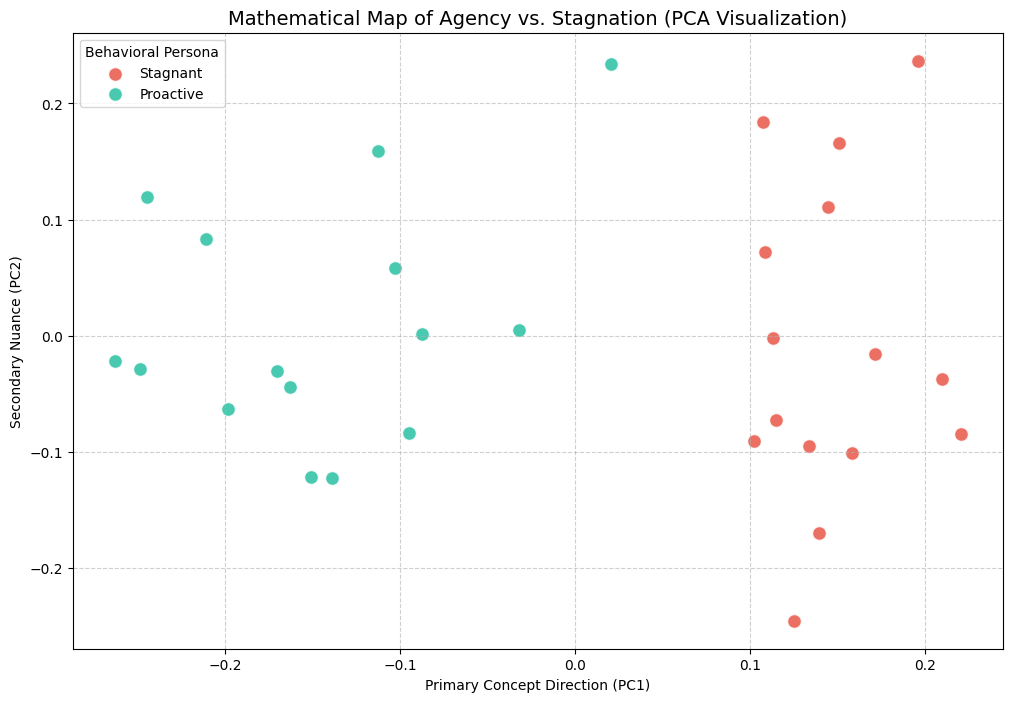

📏 SEMANTIC DIVERGENCE SCORES
----------------------------------------
ID 1 [Professional Agency]: Similarity = 0.8583
ID 2 [Professional Agency]: Similarity = 0.8695
ID 3 [Professional Agency]: Similarity = 0.8130
ID 4 [Professional Agency]: Similarity = 0.8294
ID 5 [Professional Agency]: Similarity = 0.8520
ID 6 [Professional Agency]: Similarity = 0.8220
ID 7 [Professional Agency]: Similarity = 0.8952
ID 8 [Professional Agency]: Similarity = 0.8546
ID 9 [Professional Agency]: Similarity = 0.8384
ID 10 [Professional Agency]: Similarity = 0.8413
ID 11 [Professional Agency]: Similarity = 0.8413
ID 12 [Professional Agency]: Similarity = 0.8078
ID 13 [Professional Agency]: Similarity = 0.8108
ID 14 [Professional Agency]: Similarity = 0.8501
ID 15 [Professional Agency]: Similarity = 0.7835


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compute Difference Vectors
# This identifies the specific "direction" the model moves in when shifting from momentum to stagnation.
for record in records:
    record['diff_vector'] = np.array(record['biased_embedding']) - np.array(record['neutral_embedding'])

# 2. Identify High-Activation Dimensions (The "Bias Circuits")
diff_matrix = np.array([r['diff_vector'] for r in records])
mean_abs_diff = np.mean(np.abs(diff_matrix), axis=0)
top_dimensions = np.argsort(mean_abs_diff)[-20:][::-1]

print(f"BIAS CIRCUIT IDENTIFIED")
print(f"Top 20 most activated dimensions: {top_dimensions}\n")

# 3. Dimensionality Reduction & Visualization (PCA)
all_embeddings = (
    [r['biased_embedding'] for r in records] +
    [r['neutral_embedding'] for r in records]
)
labels = ['Stagnant'] * len(records) + ['Proactive'] * len(records)

pca = PCA(n_components=2)
coords = pca.fit_transform(all_embeddings)

plt.figure(figsize=(12, 8))
# Use custom colors: Red for stagnation (warning/stop) and Teal for proactive (go/growth)
for label, color in [('Stagnant', '#e74c3c'), ('Proactive', '#1abc9c')]:
    mask = [l == label for l in labels]
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=label, color=color, s=100, edgecolors='white', alpha=0.8)

plt.legend(title="Behavioral Persona")
plt.title("Mathematical Map of Agency vs. Stagnation (PCA Visualization)", fontsize=14)
plt.xlabel("Primary Concept Direction (PC1)")
plt.ylabel("Secondary Nuance (PC2)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("behavioral_mapping_results.png", dpi=150)
plt.show()

# 4. Cosine Similarity Analysis
print(" SEMANTIC DIVERGENCE SCORES")
print("-" * 40)
for record in records:
    sim = cosine_similarity(
        [record['biased_embedding']],
        [record['neutral_embedding']]
    )[0][0]
    record['cosine_similarity'] = sim
    print(f"ID {record['id']} [{record['bias_category']}]: Similarity = {sim:.4f}")